Code created by: Lorena Espinosa, Johana Rátiva, Eduards Chipatecua 

Class: Procesamiento del Lenguaje Natural

University: Universidad de los Andes

Date: September 18, 2026

In [112]:
# Importamos las librerías necesarias para el desarrollo del laboratorio
# De ser necesario, se deben instalar las librerías que no se encuentren en el entorno de desarrollo.

import re

import kagglehub
from pathlib import Path
import matplotlib.pyplot as plt
import nltk
import pandas as pd
import seaborn as sns

from nltk.corpus import stopwords
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import f1_score

from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
)
from sklearn.model_selection import train_test_split


# NLTK es una librería particular para PLN. Tiene muchas funcionalidades entre
# ellas stemming y listas de palabras de parada.
nltk.download("stopwords")

stemmer = nltk.stem.SnowballStemmer("english")
english_stopwords = set(stopwords.words("english"))

pd.set_option("display.max_colwidth", 100)

[nltk_data] Downloading package stopwords to /home/lorena/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


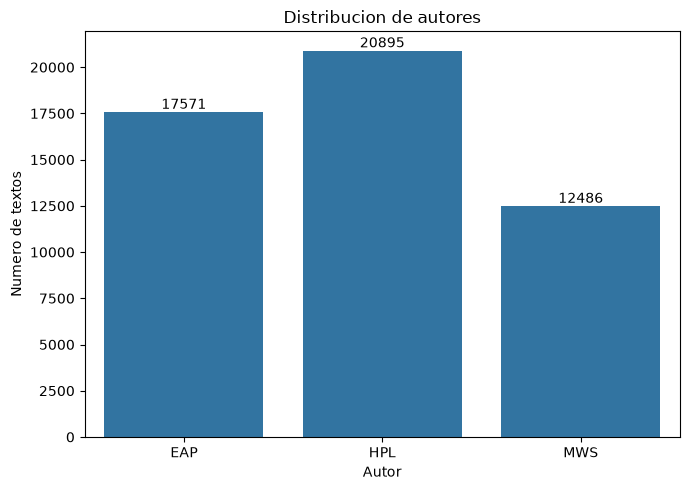

author
HPL    20895
EAP    17571
MWS    12486
Name: count, dtype: int64


In [113]:
"""Carga el conjunto de datos desde Kaggle. Guarda los textos y autores en un DataFrame. 
Luego muestra la cantidad de textos por autor."""

path = kagglehub.dataset_download("lteodor/identify-the-author")
csv_path = Path(path) / "labeled_sentence_corpus.csv"
df = pd.read_csv(csv_path)

plt.figure(figsize=(7, 5))

ax = sns.countplot(x="author", data=df)

plt.title("Distribucion de autores")
plt.xlabel("Autor")
plt.ylabel("Numero de textos")

for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()
plt.show()

print(df["author"].value_counts())


In [114]:
"""Preprocesa los textos para reducir el ruido. Elimina caracteres innecesarios. 
Convierte el texto a minusculas. Elimina palabras de parada y aplica stemming."""

def preprocess(text):
    """Clean, lowercase and stem an English message."""
    # Paso 1: Remover con una expresión regular caracteres especiales (no palabras).
    processed = re.sub(r"\W", " ", str(text))
    # Paso 2: Remover ocurrencias de caracteres individuales.
    processed = re.sub(r"\s+[a-zA-Z]\s+", " ", processed)
    # Paso 3: Remover numeros.
    processed = re.sub(r"[0-9]+", " ", processed)
    # Paso 4: Simplificar espacios consecutivos a un unico espacio entre palabras.
    processed = re.sub(r" +", " ", processed)
    # Paso 5: Pasar todo el texto a minusculas.
    processed = processed.lower()
    # Paso 6: Remover palabras de parada y aplicar stemming.
    return " ".join(
        stemmer.stem(token)
        for token in processed.split()
        if token not in english_stopwords
    )

df["processed_text"] = df["text"].apply(preprocess)

In [115]:
"""Divide los datos en conjuntos de entrenamiento. Validacion y prueba. 
Mantiene la proporcion de textos de cada autor en los tres conjuntos."""

#train_df → 60%
#val_df   → 10%
#test_df  → 30%

train_df, aux_df = train_test_split(
    df,
    test_size=0.40,
    random_state=42,
    stratify=df["author"],
)

val_df, test_df = train_test_split(
    aux_df,
    test_size=0.75,
    random_state=42,
    stratify=aux_df["author"],
)

X_train = train_df["processed_text"]
y_train = train_df["author"]

X_val = val_df["processed_text"]
y_val = val_df["author"]

X_test = test_df["processed_text"]
y_test = test_df["author"]

In [116]:
"""Convierte los textos en vectores TF IDF usando palabras. 
Ajusta el vectorizador solo con los datos de entrenamiento. 
Luego transforma validacion y prueba."""

#TF-IDF de palabras
vectorizer_word = TfidfVectorizer()

X_train_word = vectorizer_word.fit_transform(X_train)
X_val_word = vectorizer_word.transform(X_val)
X_test_word = vectorizer_word.transform(X_test)

print("Train:", X_train_word.shape)
print("Validation:", X_val_word.shape)
print("Test:", X_test_word.shape)

Train: (30571, 18878)
Validation: (5095, 18878)
Test: (15286, 18878)


In [117]:
"""Convierte los textos en vectores TF IDF usando grupos de caracteres de 
tres a cinco caracteres. Ajusta el vectorizador con entrenamiento y transforma 
los otros conjuntos."""

#TF-IDF de palabras con n-gramas en donde n -> 3..5
vectorizer_char = TfidfVectorizer(
    analyzer="char",
    ngram_range=(3, 5)
)

X_train_char = vectorizer_char.fit_transform(X_train)
X_val_char = vectorizer_char.transform(X_val)
X_test_char = vectorizer_char.transform(X_test)

print("Train:", X_train_char.shape)
print("Validation:", X_val_char.shape)
print("Test:", X_test_char.shape)

Train: (30571, 178070)
Validation: (5095, 178070)
Test: (15286, 178070)


### Naive Bayes

#### Entrenamiento con DF-IDF (Palabras)

In [118]:
"""Entrena varios modelos Naive Bayes usando TF IDF de palabras. 
Cambia el valor de alpha y guarda el F1 macro de entrenamiento y 
validacion para cada modelo."""

valores_alpha = [0.01, 0.1, 0.5, 1, 5, 10]
resultados_nb_word = []

for alpha in valores_alpha:
    #Crear el modelo a partir del alpha variable
    modelo = MultinomialNB(alpha=alpha)
    #Entrenar el modelo
    modelo.fit(X_train_word, y_train)
    #Evaluar el modelo
    pred_train = modelo.predict(X_train_word)
    pred_val = modelo.predict(X_val_word)

    f1_train = f1_score(y_train, pred_train, average="macro")
    f1_val = f1_score(y_val, pred_val, average="macro")

    resultados_nb_word.append({
        "Alpha": alpha,
        "Train F1 macro": f1_train,
        "Validation F1 macro": f1_val
    })

In [119]:
resultados_nb_word = pd.DataFrame(resultados_nb_word)
resultados_nb_word

,Alpha,Train F1 macro,Validation F1 macro
0,0.01,0.910675,0.828801
1,0.10,0.904267,0.832616
2,0.50,0.889839,0.823226
3,1.00,0.872942,0.811528
4,5.00,0.760219,0.717424
5,10.00,0.672233,0.636519


Aqui se ve un comportamiento bastante claro: con alpha=0.01, el F1 de validacion es 0.829, pero aumenta ligeramente a 0.833 con alpha=0.1, que es el mejor resultado. A partir de ahi, al incrementar alpha, el rendimiento disminuye progresivamente. Esto indica que una suavizacion demasiado fuerte perjudica al modelo, mientras que una suavizacion moderada mejora la generalizacion. Ademas, la diferencia entre train y validation es relativamente pequeña en alpha=0.1, por lo que alpha=0.1 presenta el mejor equilibrio en este experimento.

#### Entrenamiento con DF-IDF (Caracteres)

In [120]:
"""Entrena varios modelos Naive Bayes usando TF IDF de caracteres. 
Cambia el valor de alpha y guarda el F1 macro de entrenamiento y 
validacion para cada modelo."""

valores_alpha = [0.01, 0.1, 0.5, 1, 5, 10]
resultados_nb_char = []

for alpha in valores_alpha:
    modelo = MultinomialNB(alpha=alpha)

    modelo.fit(X_train_char, y_train)

    pred_train = modelo.predict(X_train_char)
    pred_val = modelo.predict(X_val_char)

    f1_train = f1_score(y_train, pred_train, average="macro")
    f1_val = f1_score(y_val, pred_val, average="macro")

    resultados_nb_char.append({
        "Alpha": alpha,
        "Train F1 macro": f1_train,
        "Validation F1 macro": f1_val
    })


In [121]:
resultados_nb_char = pd.DataFrame(resultados_nb_char)
resultados_nb_char

,Alpha,Train F1 macro,Validation F1 macro
0,0.01,0.932429,0.812059
1,0.10,0.905344,0.805067
2,0.50,0.844135,0.753302
3,1.00,0.749212,0.673294
4,5.00,0.437429,0.377398
5,10.00,0.332507,0.293641


En caracteres, el mejor resultado de validacion se obtiene con alpha=0.01, con un F1 de 0.812. A medida que aumenta alpha, tanto el F1 de entrenamiento como el de validacion disminuyen, lo que indica que una mayor suavizacion perjudica el rendimiento del modelo. Ademas, la diferencia entre entrenamiento y validacion es mayor con alpha=0.01, pero sigue siendo el valor que ofrece el mejor desempeño de validacion en este experimento.

### Regresion logistica

#### Entrenamiento con DF-IDF (Palabras)

In [122]:
"""Entrena varios modelos de regresion logistica usando TF IDF de palabras. 
Cambia el valor de C y guarda el F1 macro de entrenamiento y 
validacion para cada modelo."""

valores_C = [0.01, 0.1, 1, 10, 100]
resultados_lr_word = []

for C in valores_C:
    #Crear el modelo a partir del C variable
    modelo = SGDClassifier(
        C=C,
        max_iter=1000,
        random_state=42
    )

    #Entrenar el modelo
    modelo.fit(X_train_word, y_train)
    #Evaluar el modelo
    pred_train = modelo.predict(X_train_word)
    pred_val = modelo.predict(X_val_word)

    f1_train = f1_score(y_train, pred_train, average="macro") #quq tanto se esta ajustando al conjunto de entrenamiento.
    f1_val = f1_score(y_val, pred_val, average="macro") ## que tan bien generaliza el modelo.

    resultados_lr_word.append({
        "C": C,
        "Train F1 macro": f1_train,
        "Validation F1 macro": f1_val
    })

TypeError: SGDClassifier.__init__() got an unexpected keyword argument 'C'

In [ ]:
resultados_lr_word = pd.DataFrame(resultados_lr_word)
resultados_lr_word

Los resultados muestran que, con valores bajos de C, el modelo presenta subajuste, ya que tanto el F1 de entrenamiento como el de validacion son bajos. Al aumentar C, el desempeño mejora hasta alcanzar el mejor F1 de validacion con C=10 (0.827). Sin embargo, con C=100 el F1 de entrenamiento sigue aumentando mientras el de validacion disminuye a 0.808, lo que indica un mayor sobreajuste al reducir demasiado la regularizacion.

#### Entrenamiento con DF-IDF (Caracteres)

In [ ]:
"""Entrena varios modelos de regresion logistica usando TF IDF de caracteres. 
Cambia el valor de C y guarda el F1 macro de entrenamiento y validacion para cada modelo."""

valores_C = [0.01, 0.1, 1, 10, 100]
resultados_lr_char = []

for C in valores_C:
    #Crear el modelo a partir del C variable
    modelo = SGDClassifier(
        C=C,
        max_iter=1000,
        random_state=42
    )
    #Entrenar el modelo
    modelo.fit(X_train_char, y_train)
    #Evaluar el modelo
    pred_train = modelo.predict(X_train_char)
    pred_val = modelo.predict(X_val_char)

    f1_train = f1_score(y_train, pred_train, average="macro")
    f1_val = f1_score(y_val, pred_val, average="macro")

    resultados_lr_char.append({
        "C": C,
        "Train F1 macro": f1_train,
        "Validation F1 macro": f1_val
    })

In [ ]:
resultados_lr_char = pd.DataFrame(resultados_lr_char)
resultados_lr_char

En caracteres vemos un comportamiento similar. Con C=0.01 y C=0.1 hay subajuste, ya que los F1 de entrenamiento y validacion son bajos. Al aumentar C, el rendimiento mejora hasta C=10, donde se obtiene el mayor F1 de validacion (0.818). Con C=100, el F1 de entrenamiento sigue aumentando hasta 0.999, mientras que el de validacion baja ligeramente a 0.812, lo que muestra un aumento del sobreajuste. En este caso, aumentar C mas alla de 10 no mejora la generalizacion.

### Resumen de la evaluacion de los modelos

In [ ]:
"""Construye un resumen con el mejor hiperparametro de cada configuracion. 
Incluye el F1 macro de entrenamiento y validacion para comparar los modelos."""

resumen = pd.DataFrame([
    [
        "Naive Bayes",
        "Palabras",
        resultados_nb_word.loc[
            resultados_nb_word["Validation F1 macro"].idxmax(), "Alpha"
        ],
        resultados_nb_word.loc[
            resultados_nb_word["Validation F1 macro"].idxmax(), "Train F1 macro"
        ],
        resultados_nb_word["Validation F1 macro"].max()
    ],
    [
        "Naive Bayes",
        "Caracteres",
        resultados_nb_char.loc[
            resultados_nb_char["Validation F1 macro"].idxmax(), "Alpha"
        ],
        resultados_nb_char.loc[
            resultados_nb_char["Validation F1 macro"].idxmax(), "Train F1 macro"
        ],
        resultados_nb_char["Validation F1 macro"].max()
    ],
    [
        "Logistic Regression",
        "Palabras",
        resultados_lr_word.loc[
            resultados_lr_word["Validation F1 macro"].idxmax(), "C"
        ],
        resultados_lr_word.loc[
            resultados_lr_word["Validation F1 macro"].idxmax(), "Train F1 macro"
        ],
        resultados_lr_word["Validation F1 macro"].max()
    ],
    [
        "Logistic Regression",
        "Caracteres",
        resultados_lr_char.loc[
            resultados_lr_char["Validation F1 macro"].idxmax(), "C"
        ],
        resultados_lr_char.loc[
            resultados_lr_char["Validation F1 macro"].idxmax(), "Train F1 macro"
        ],
        resultados_lr_char["Validation F1 macro"].max()
    ]
], columns=[
    "Modelo",
    "Representacion",
    "Hiperparametro",
    "Train F1 macro",
    "Validation F1 macro"
])

resumen

El Naive Bayes con representacion de palabras y alpha=0.10 obtiene el mayor F1 de validacion (0.833). Ademas, presenta una diferencia menor entre entrenamiento y validacion que las configuraciones de regresion logistica, lo que indica un comportamiento de generalizacion mas estable en este experimento.

Por lo tanto, la configuracion seleccionada para la evaluacion final es:

Modelo: Naive Bayes

Representacion: TF-IDF de palabras

alpha: 0.10

Validation F1 macro: 0.832616

### Construccion del modelo a usar

In [ ]:
"""Obtiene automaticamente el alpha que produjo el mejor F1 macro de validacion. 
Con ese valor crea el modelo final. Luego entrena el modelo y genera las predicciones 
del conjunto de prueba."""

mejor_alpha = resultados_nb_word.loc[
    resultados_nb_word["Validation F1 macro"].idxmax(),
    "Alpha"
]
nb_final = MultinomialNB(alpha=mejor_alpha)

nb_final.fit(X_train_word, y_train)

pred_nb_test = nb_final.predict(X_test_word)

#### Evaluacion

In [ ]:
"""Calcula el Accuracy y muestra el reporte de clasificacion del modelo final sobre el conjunto 
de prueba."""

print("Accuracy:", accuracy_score(y_test, pred_nb_test))

print(
    classification_report(
        y_test,
        pred_nb_test,
        digits=3
    )
)

El modelo obtuvo un Accuracy de 0.845, lo que significa que aproximadamente el 84.5% de las predicciones realizadas sobre el conjunto de test fueron correctas. Esto muestra que el modelo logra clasificar correctamente la mayoria de los textos, aunque todavia existe un porcentaje de casos donde confunde entre los diferentes autores.

In [ ]:
"""Calcula el F1 micro y el F1 macro del modelo final sobre el conjunto de prueba."""

f1_micro = f1_score(
    y_test,
    pred_nb_test,
    average="micro"
)
f1_macro = f1_score(
    y_test,
    pred_nb_test,
    average="macro"
)
print("F1 micro:", f1_micro)
print("F1 macro:", f1_macro)

El F1 micro fue de 0.845, lo que indica un buen desempeño considerando todas las predicciones en conjunto. Ademas, el F1 macro fue de 0.839, superando el 0.82 solicitado. El F1 micro es muy similar al Accuracy (0.845), lo que muestra que el rendimiento general del modelo es consistente.

In [ ]:
"""Calcula la matriz de confusion del modelo final. Luego muestra la cantidad de predicciones correctas y errores para cada autor."""

cm = confusion_matrix(y_test, pred_nb_test)

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=nb_final.classes_
).plot()

plt.title("Matriz de confusion - Naive Bayes")
plt.show()

La matriz de confusion permite ver no solo cuantos textos clasifica bien el modelo, sino tambien que tan facil o dificil es diferenciar a cada autor. HPL es el autor que el modelo identifica con mayor facilidad, ya que acierta 5660 de 6269 textos, y solo confunde 442 con EAP y 167 con MWS. Esto sugiere que las caracteristicas presentes en los textos de HPL son relativamente mas faciles de distinguir de las de los otros autores. En cambio, EAP presenta mas dificultad, especialmente porque 601 textos de EAP son clasificados como HPL, siendo la confusion mas grande de toda la matriz. Esto significa que existe una mayor similitud entre las caracteristicas que el modelo aprendio de EAP y HPL. Algo parecido ocurre con MWS, donde 421 textos son confundidos con EAP y 326 con HPL, por lo que sus caracteristicas son menos faciles de separar. En general, la matriz muestra que el modelo no tiene un problema general para clasificar los autores, sino que sus principales dificultades aparecen cuando debe diferenciar autores que tienen caracteristicas textuales similares. Esto tambien ayuda a explicar por que el F1 macro es 0.839: aunque el rendimiento global es bueno y supera el 0.82 solicitado, no todos los autores son reconocidos con la misma facilidad.